<a href="https://colab.research.google.com/github/Nicolsag/Detec-o-de-Dengue-com-Machine-Learning/blob/main/Detec%C3%A7%C3%A3o_de_Dengue_com_Machine_Learning_a_partir_de_Dados_Cl%C3%ADnicos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Conjunto de dados para detecção de dengue (dados clínicos**)




Para este modelo, usaremos o seguinte dataset:

https://www.kaggle.com/datasets/aravind3505/dengue-detection-dataset-clinical-data

<br>

### Informações do dataset:

<br>

## 📁 Features
* age: Idade do paciente;
* gender: Homem ou Mulher;
* hemoglobin_g_dl: Nível de hemoglobina (g/dL);
* wbc_count: Contagem de células brancas;
* differential_count: Diferencial * Contagem WBC;
* rbc_count: Contagem de células vermelhas no sangue;
* platelet_count: Contagem de plaquetas;
* platelet_distribution_width: * Platelet size variation (PDW);
* dengue_label: Target variable (0 = * No Dengue, 1 = Dengue).

<br>

## 🧹 Pré-processamento de dados:
*   Valores ausentes removidos;
*   Registros duplicados tratados;
*   Nomenclatura padronizada de recursos para consistência.

<br>

##⚠️ Aviso Legal:

* Este conjunto de dados destina-se exclusivamente a fins educativos e não deve ser utilizado para diagnósticos médicos na prática clínica.
<br>

## Fazendo conexão com o Google Drive para trazer o dataset:

<br>

In [37]:
from google.colab import drive
import pandas as pd
from sklearn import set_config

drive.mount('/content/drive')

df = pd.read_csv('/content/drive/MyDrive/datasets for training/TratamentoDengue.csv') ## <- caminho do dataset
set_config(transform_output="pandas")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [38]:
df.head()

,age,dengue_label,differential_count,gender,hemoglobin_g_dl,platelet_count,platelet_distribution_width,rbc_count,wbc_count
0,4,1,0,2,112,30000,16,1,2700
1,12,1,0,1,142,88000,158,1,2200
2,14,1,0,1,13,113000,14,1,3400
3,15,1,0,0,146,19067,196,1,2700
4,15,1,0,1,15,67000,13,1,3500


<br>

## Inserindo um gráfico de matriz de correlação *(heatmap)*



* Aqui iremos checar as variáveis da nossa tabela e filtrar o que não for útil para o nosso modelo:

<br>

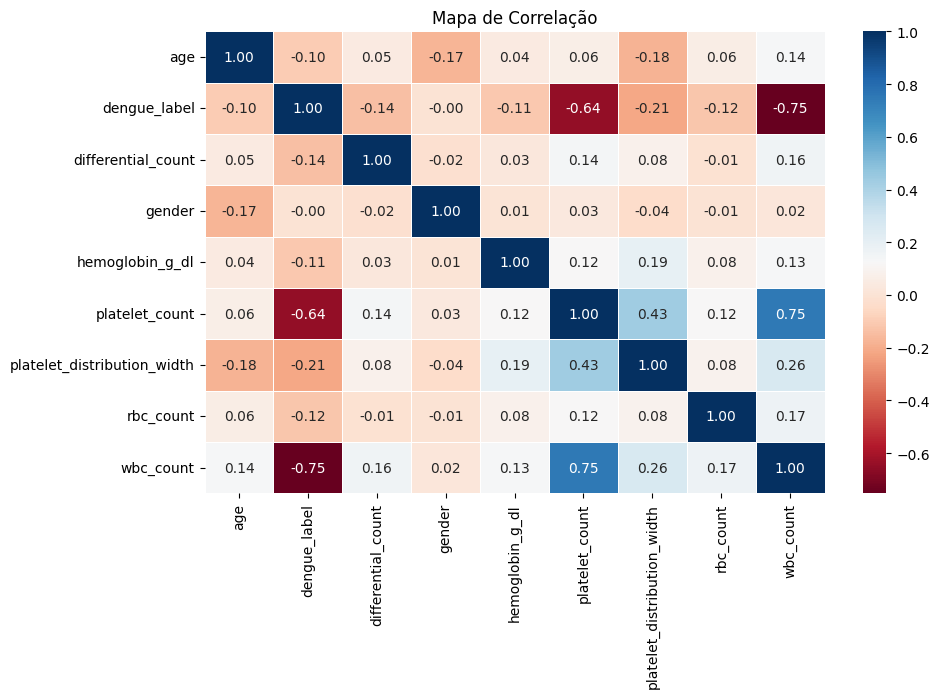

In [39]:
import seaborn as sns
import matplotlib.pyplot as plt

corr = df.corr(numeric_only=True)

# Cria o gráfico
plt.figure(figsize=(10, 6))
sns.heatmap(
    corr,
    annot=True,       # mostra os valores
    fmt=".2f",        # 2 casas decimais
    cmap="RdBu",      # cores
    linewidths=0.5
)

plt.title("Mapa de Correlação")
plt.show()

# Filtrando e removendo os dados:



#### Os dados em questão foram:

* Removidos: `differential_count`, `gender`, `age` e `rbc_count`;

* E sendo `dengue_label` a nossa coluna y.

In [40]:
X = df.drop(['dengue_label', 'differential_count', 'gender', 'age', 'rbc_count'], axis=1)
y = df['dengue_label']

<br>

## Importando as bibliotecas que serão utilizadas no projeto:

<br>

In [41]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.metrics import recall_score, accuracy_score, precision_score, f1_score
from sklearn.metrics import ConfusionMatrixDisplay, RocCurveDisplay, confusion_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
import numpy as np
from scipy.stats import loguniform, randint

# Escolhendo os modelos utilizados e definição de hiperparamâmetros

#### Os modelos em questão utilizados no projeto foram:
* LogisticRegression,
* RandomForestClassifier,
* AdaBoostClassifier,
* XGBClassifier,
* LGBMClassifier.
<br>

#### OBS:

A estrutura de organização desses modelos foi feita por meio de um dicionário, no qual cada entrada contém duas informações principais: a chave "modelo", que representa o algoritmo e sua respectiva inicialização, e a chave "params", destinada à configuração dos hiperparâmetros específicos de cada modelo.

In [42]:
modelos = {
    "LogisticRegression": {
        "modelo": LogisticRegression(),
        "params": {
            "modelo__C": loguniform(0.001, 1)
        }
    },

    "RandomForestClassifier": {
        "modelo": RandomForestClassifier(),
        "params": {
            "modelo__max_depth": randint(3, 10),
            "modelo__min_samples_split": randint(2, 10),
            "modelo__min_samples_leaf": randint(1, 5)
        }
    },

    "AdaBoostClassifier": {
        "modelo": AdaBoostClassifier(),
        "params": {
            "modelo__learning_rate": loguniform(0.01, 0.1),
            "modelo__n_estimators": randint(10, 50)
        }
    },

    "XGBClassifier": {
        "modelo": XGBClassifier(),
        "params": {
            "modelo__n_estimators": randint(100, 500),
            "modelo__learning_rate": loguniform(0.01, 0.3),
            "modelo__max_depth": randint(3, 10),
            "modelo__subsample": loguniform(0.6, 1.0),
            "modelo__colsample_bytree": loguniform(0.6, 1.0),
            "modelo__gamma": loguniform(1e-3, 1),
            "modelo__min_child_weight": randint(1, 10),
            "modelo__reg_lambda": loguniform(1e-2, 10)
        }
    },

    "LGBMClassifier": {
        "modelo": LGBMClassifier(verbose=-1),
        "params": {
           "modelo__n_estimators": randint(100, 500),
           "modelo__learning_rate": loguniform(0.01, 0.3, 0.10),
           "modelo__num_leaves": randint(15, 120),
           "modelo__max_depth": randint(3, 15),
           "modelo__feature_fraction": loguniform(0.6, 1.0),
           "modelo__bagging_fraction": loguniform(0.6, 1.0),
           "modelo__min_data_in_leaf": randint(5, 50),
           "modelo__lambda_l1": loguniform(1e-3, 10),
           "modelo__lambda_l2": loguniform(1e-3, 10)
        }
    }
}

# Divisão dos dados e treinamento dos modelos
Nesta etapa, os dados são divididos em conjuntos de treino e teste, utilizando `train_test_split` com `stratify=y` para manter a proporção das classes.

Em seguida, os diferentes modelos são treinados utilizando um pipeline que inclui padronização dos dados (`StandardScaler`) e o algoritmo em si.

Para cada modelo, é aplicada uma busca aleatória de hiperparâmetros com `RandomizedSearchCV`, utilizando validação cruzada e a métrica ROC AUC como critério de avaliação.

Ao final, é selecionado o modelo com melhor desempenho médio na validação cruzada.

In [43]:
## Train_test

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

resultados = {}

## Aplicando Pipeline e Randomized

for nome, config in modelos.items():
    print(f'Treinando: {nome}')

    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('modelo', config["modelo"])
    ])

    search = RandomizedSearchCV(
        pipe, config["params"],
        scoring="roc_auc",
        n_iter=50,
        n_jobs=-1,
        random_state=42,
        cv=5
    )

    search.fit(X_train, y_train)
    resultados[nome] = search

## Obtendo os melhores parâmetros

melhor_nome = max(resultados, key=lambda x: resultados[x].best_score_)
best_model = resultados[melhor_nome].best_estimator_

print("\n==== Melhores parâmetros ====")
print(resultados[melhor_nome].best_params_)
print(f"\nModelo: {melhor_nome}")
print("Melhor score (CV):", resultados[melhor_nome].best_score_)

Treinando: LogisticRegression
Treinando: RandomForestClassifier
Treinando: AdaBoostClassifier
Treinando: XGBClassifier
Treinando: LGBMClassifier

==== Melhores parâmetros ====
{'modelo__bagging_fraction': np.float64(0.6925326412960738), 'modelo__feature_fraction': np.float64(0.6074992094736816), 'modelo__lambda_l1': np.float64(0.3818468247973969), 'modelo__lambda_l2': np.float64(0.0051102567156543965), 'modelo__learning_rate': np.float64(0.34500297851058137), 'modelo__max_depth': 7, 'modelo__min_data_in_leaf': 10, 'modelo__n_estimators': 198, 'modelo__num_leaves': 119}

Modelo: LGBMClassifier
Melhor score (CV): 0.9033710469695124


# Geração de probabilidades e ajuste do threshold
Com o melhor modelo definido, são geradas as probabilidades da classe positiva no conjunto de teste.

A partir dessas probabilidades, diferentes valores de threshold são avaliados com o objetivo de ajustar a decisão de classificação.

O critério adotado é manter um recall mínimo de 0.90, priorizando a redução de falsos negativos.

Entre os thresholds que atendem a esse critério, é selecionado aquele que apresenta o menor custo total, calculado com base em penalizações distintas para falsos positivos e falsos negativos.

In [44]:
y_proba = best_model.predict_proba(X_test)[:, 1]

## Aplicação dos parâmetros do Threshold
threshold = np.arange(0.5, 0.9, 0.01)

## Adicionando valor para FN e FP
custo_FP = 100
custo_FN = 3000

## Guardando os resultados
results = []

for t in threshold:
    y_pred = (y_proba >= t).astype(int)
    recall = recall_score(y_test, y_pred)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    custo_total = fn * custo_FN + fp * custo_FP

    if recall >= 0.90: ## Ajustando recall de 0.90
        results.append({
            "threshold": t,
            "recall": recall,
            "FN": fn,
            "FP": fp,
            "custo_total": custo_total
        })

## Apresentando os resultados

if results:
    df_resultados = pd.DataFrame(results)
    df_resultados = df_resultados.sort_values(by="custo_total").reset_index(drop=True)
    best_t = df_resultados.loc[0, 'threshold']

    print("\n==== Melhores thresholds e custos ====")
    print(df_resultados.head(5))
else:
    print("\nNenhum threshold encontrou recall >= 0.90.")


==== Melhores thresholds e custos ====
   threshold    recall  FN  FP  custo_total
0       0.50  0.945055  10  16        31600
1       0.51  0.945055  10  16        31600
2       0.52  0.945055  10  16        31600
3       0.53  0.945055  10  16        31600
4       0.54  0.939560  11  16        34600


# Predição final e avaliação do modelo
Utilizando o threshold selecionado, as probabilidades são convertidas em classes preditas.

Em seguida, o modelo é avaliado no conjunto de teste por meio das métricas de classificação:

- acurácia
- precisão
- recall
- F1-score

Essas métricas permitem analisar o desempenho geral do modelo após o ajuste do threshold.

In [45]:
print(type(best_model))
print(best_model)

<class 'sklearn.pipeline.Pipeline'>
Pipeline(steps=[('scaler', StandardScaler()),
                ('modelo',
                 LGBMClassifier(bagging_fraction=np.float64(0.6925326412960738),
                                feature_fraction=np.float64(0.6074992094736816),
                                lambda_l1=np.float64(0.3818468247973969),
                                lambda_l2=np.float64(0.0051102567156543965),
                                learning_rate=np.float64(0.34500297851058137),
                                max_depth=7, min_data_in_leaf=10,
                                n_estimators=198, num_leaves=119,
                                verbose=-1))])


In [46]:
y_pred = (y_proba >= best_t).astype(int)

## Avaliando o modelo

print("\n===== Avaliação do Modelo =====")
print("Acurácia :", accuracy_score(y_test, y_pred))
print("Precisão :", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1-score :", f1_score(y_test, y_pred))


===== Avaliação do Modelo =====
Acurácia : 0.9071428571428571
Precisão : 0.9148936170212766
Recall   : 0.945054945054945
F1-score : 0.9297297297297298


# Análise visual dos resultados
Para complementar a avaliação, são utilizadas visualizações que permitem uma análise mais detalhada do desempenho do modelo.

A matriz de confusão normalizada é empregada para observar a distribuição dos acertos e erros entre as classes.

Além disso, a curva ROC é utilizada para avaliar a capacidade do modelo em separar as classes ao longo de diferentes limiares de decisão.

<Figure size 1000x600 with 0 Axes>

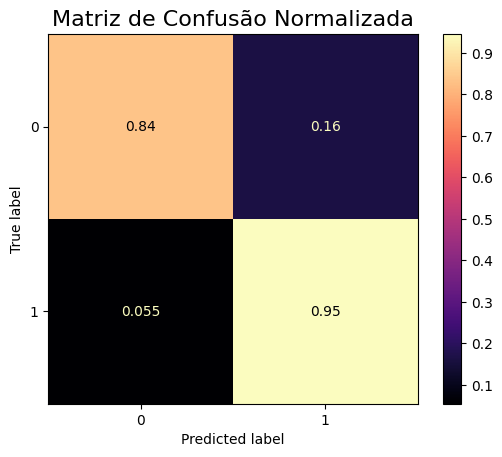

In [47]:
## gerando Matriz de confusão

plt.figure(figsize=(10,6))
cm = confusion_matrix(y_test, y_pred, normalize='true')

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0,1])
disp.plot(cmap='magma')

plt.title("Matriz de Confusão Normalizada", fontsize=16)
plt.show()

<Figure size 800x600 with 0 Axes>

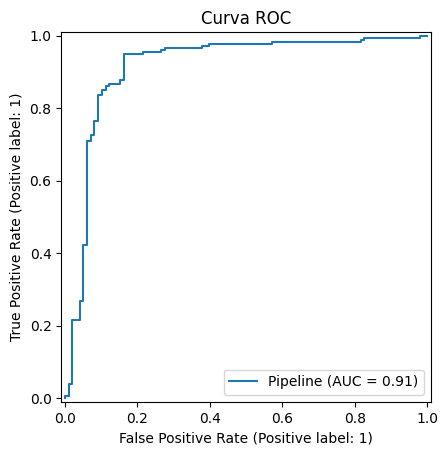

In [48]:
## Gerando Curva Roc

plt.figure(figsize=(8,6))
RocCurveDisplay.from_estimator(best_model, X_test, y_test)
plt.title("Curva ROC")
plt.show()

# Interpretação dos resultados

O modelo selecionado apresentou bom desempenho na identificação de casos positivos, com recall de 0.90, evidenciando alta capacidade de detecção de ocorrências de dengue.

A taxa de falsos negativos obtida foi de 0.055. Embora execuções anteriores tenham apresentado valores inferiores, o resultado atual foi mantido por representar maior estabilidade e consistência metodológica após os ajustes realizados no processo de avaliação.

O ajuste do threshold foi determinante para esse comportamento, permitindo priorizar a redução de falsos negativos, ainda que com aumento controlado de falsos positivos. Essa decisão é adequada ao contexto do problema, no qual a não detecção de um caso positivo pode gerar consequências mais críticas.

Apesar do impacto em métricas como precisão e acurácia, o modelo se mostra mais adequado para cenários onde a sensibilidade é o principal critério de desempenho.

De forma geral, os resultados indicam que a combinação entre seleção de modelo, otimização de hiperparâmetros e ajuste de threshold contribuiu para um desempenho alinhado aos objetivos do problema.


Como melhoria futura, pode-se explorar técnicas adicionais de balanceamento de dados, ajuste fino de hiperparâmetros ou validação mais robusta para aumentar ainda mais a capacidade de generalização do modelo.